In [238]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

In [239]:
# Criteria names
criteria = ["C1", "C2", "C3", "C4"]

# Define alternatives
alternative_A = [9, (7, 0.7), [8, 8, 7], {2:3}]  # Criterion values for alternative A
alternative_B = [6, (6, 0.6), [7, 8, 6], {1:2}]  # Criterion values for alternative B
alternative_C = [2, (3, 0.3), [9, 6, 8], {3:6}]  # Criterion values for alternative C
alternatives = [alternative_A, alternative_B, alternative_C]

weights = [
    [(0.2, 0.25), (0.21, 0.26), (0.19, 0.24), (0.22, 0.27)],  # Criterion 1
    [(0.23, 0.3), (0.24, 0.31), (0.22, 0.29), (0.25, 0.32)],   # Criterion 2
    [(0.3, 0.4), (0.31, 0.41), (0.29, 0.39), (0.32, 0.42)],   # Criterion 3
    [(0.25, 0.35), (0.26, 0.36), (0.24, 0.34), (0.27, 0.37)]    # Criterion 4
]

# Results of value function elicitation
C1_vf_a_points = [0, 3, 5, 6, 10]
C1_vf_b_points = [0, 2, 4, 7, 10]
C2_vf_a_points = [0, 4, 6, 8, 10]
C2_vf_b_points = [0, 3, 5, 7, 10]
C3_vf_a_points = [0, 2, 7, 9, 10]
C3_vf_b_points = [0, 1, 6, 8, 10]
C4_vf_a_points = [0, 1, 4, 6, 10]
C4_vf_b_points = [0, 2, 5, 7, 10]

In [240]:
bin_size = 100
sim_runs = 1000

In [241]:
elicitation_values = [0, 0.25, 0.5, 0.75, 1]
def value_function(*points):
    x = np.linspace(0, 10, 100)
    value_functions = []
    for point in points:
        vf = PchipInterpolator(point, elicitation_values)
        value_functions.append(vf)

    return value_functions

vf_C1 = value_function(C1_vf_a_points, C1_vf_b_points)
vf_C2 = value_function(C2_vf_a_points, C2_vf_b_points)
vf_C3 = value_function(C3_vf_a_points, C3_vf_b_points)
vf_C4 = value_function(C4_vf_a_points, C4_vf_b_points)

vf_list = [vf_C1, vf_C2, vf_C3, vf_C4]

In [242]:
# Value sampling function
def sample_to_values(input_data, value_function):
    if isinstance(input_data, tuple):
        mean, std_dev = input_data
        sample = norm.rvs(loc=mean, scale=std_dev)
        value = value_function(sample)
        return value

    elif isinstance(input_data, list):
        # Discrete set
        unique_values, counts = np.unique(input_data, return_counts=True)
        probabilities = counts / len(input_data)
        chosen_value = np.random.choice(unique_values, p=probabilities)
        value = value_function(chosen_value)
        return value
    
    elif isinstance(input_data, dict):
        # Uniform distribution
        start = float(list(input_data.keys())[0])
        end = float(list(input_data.values())[0])
        sample = np.random.uniform(start, end)
        value = value_function(sample)
        return value
    else:
        # Exact value
        value = value_function(input_data)
        return value

In [243]:
# Compute overall distribution of weights by combining all uniform distributions
weight_distributions = []
for set_elicited_weights in weights:
    weight_array = np.zeros(bin_size)
    for weight_ranges in set_elicited_weights:
        minimum = weight_ranges[0]
        maximum = weight_ranges[1]
        # Find indices in the bins
        start_idx = int((minimum / 1.0) * bin_size)
        end_idx = int((maximum / 1.0) * bin_size)
        weight_array[start_idx:end_idx] += 1 / (maximum - minimum +1)
    weight_distributions.append(weight_array/np.sum(weight_array))

In [244]:
def weighted_sum(intermediate_results):
    total = 0
    for weight, value in intermediate_results:
        total += weight * value
    return total

def geometric_mean(intermediate_results):
    product = 1
    for weight, value in intermediate_results:
        product *= value ** weight
    return product

def harmonic_mean(intermediate_results):
    denom = 0
    for weight, value in intermediate_results:
        if value != 0:
            denom += weight / value
        else:
            return 0
    return 1 / denom

def minimum(intermediate_results):
    min_value = min(value for weight, value in intermediate_results)
    return min_value

def maximum(intermediate_results):
    max_value = max(value for weight, value in intermediate_results)
    return max_value

In [245]:
results = []
aggregation_method = weighted_sum
strict = False
for _ in range(sim_runs):
    temp_results = []
    for a, alt in enumerate(alternatives):
        # Sample weights for each criterion
        sampled_weights = []
        for c, criterion_data in enumerate(alt):
            if strict:
               continue
            else:
                weight_bins = np.linspace(0, 1, bin_size)
                probs = weight_distributions[c] / np.sum(weight_distributions[c])
                chosen_idx = np.random.choice(len(weight_bins), p=probs)
                sampled_weights.append(weight_bins[chosen_idx])
        # Normalize weights to sum to 1
        total_weight = sum(sampled_weights) 
        sampled_weights = [w / total_weight for w in sampled_weights]

        # Compute weighted values for each criterion
        intermediate_results = []
        for c, criterion_data in enumerate(alt):
            if strict:
                v_f = np.random.choice(vf_list[c]) # Value function sampling
                value = sample_to_values(criterion_data, v_f) # Data sampling
                weight = sampled_weights[c]
                intermediate_results.append([weight ,value])
            else:
                value_function_results = []
                for v_f in vf_list[c]:
                    value = sample_to_values(criterion_data, v_f) # Data sampling
                    value_function_results.append(value)
                # Construct a distribution over the values obtained from different value functions
                mean_value = np.mean(value_function_results)
                std_value = np.std(value_function_results)
                sampled_value = np.random.normal(loc=mean_value, scale=std_value)
                weight = sampled_weights[c]
                intermediate_results.append([weight ,sampled_value])

        # Aggregation
        alternative_value = aggregation_method(intermediate_results)
        temp_results.append(alternative_value)

    results.append(temp_results)   

In [246]:
results = np.array(results)  # Shape: (sim_runs, num_alternatives)
num_alternatives = results.shape[1]
for i in range(num_alternatives):
    res = results[:,i]
    MC_avg = np.mean(res)
    MC_std = np.sqrt(1/(len(res)*(len(res)-1)) * np.sum((res - MC_avg)**2))
    print(f"MC Average: {MC_avg:.4f}, MC Std Dev: {MC_std:.4f}, MC relative std dev: {MC_std/MC_avg*100:.2f}%")

MC Average: 0.6301, MC Std Dev: 0.0013, MC relative std dev: 0.21%
MC Average: 0.5100, MC Std Dev: 0.0014, MC relative std dev: 0.28%
MC Average: 0.4267, MC Std Dev: 0.0018, MC relative std dev: 0.41%


1.0


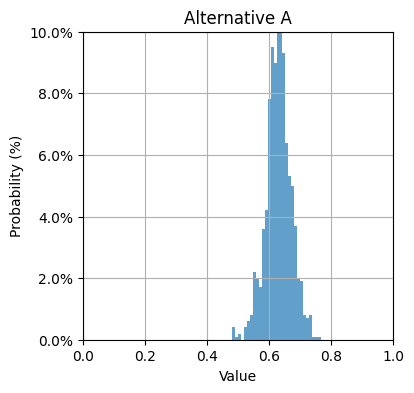

1.0


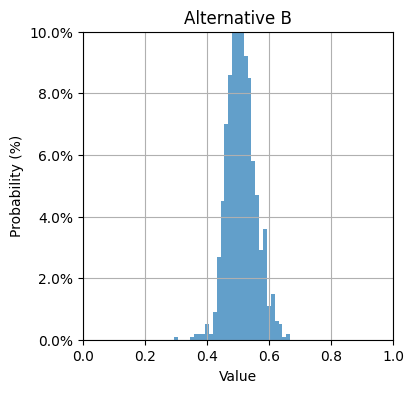

1.0


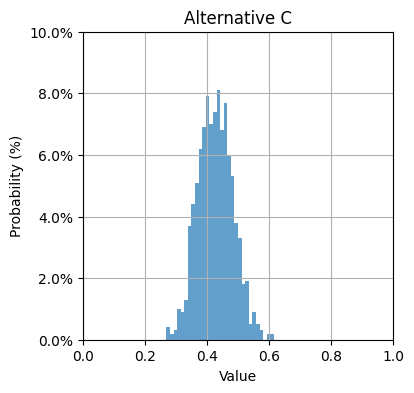

In [250]:
# Plot histograms of overall alternative values
# each results[i] is a run and contains a value for each alternative
for alt_idx in range(num_alternatives):
    # First compute the histogram
    hist, bin_edges = np.histogram(results[:, alt_idx], bins=30)
    hist_prob = hist / sim_runs  # Normalize to get probabilities
    print(sum(hist_prob))
    plt.figure(figsize=(4, 4))
    plt.bar(bin_edges[:-1], hist_prob, width=np.diff(bin_edges), align='edge', alpha=0.7)
    plt.xlabel("Value")
    plt.ylabel("Probability")
    plt.ylim(0,0.1)
    ax = plt.gca()
    ax.set_ylabel("Probability (%)")
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{y*100:.1f}%' for y in yticks])
    plt.title(f"Alternative {chr(65 + alt_idx)}")
    plt.grid()
    plt.xlim(0, 1)
    plt.show()